In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
columns = [ "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation", 
           "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income" ] 

In [3]:
df_train = pd.read_csv(r"C:\Users\gowri\OneDrive\adult.data", header=None, names=columns, na_values="?", skipinitialspace=True) 

In [4]:
df_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df_test = pd.read_csv(r"C:\Users\gowri\OneDrive\adult\adult.test", header=None, names=columns, na_values="?", skipinitialspace=True,skiprows=1)

In [5]:
df_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


In [6]:
df_train["source"] = "train"
df_test["source"] = "test"

In [7]:
df_train_test = pd.concat([df_train, df_test], ignore_index=True)

In [8]:
#Age
df_train_test['age'].describe()

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [9]:
df_train_test['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: age
Non-Null Count  Dtype
--------------  -----
48842 non-null  int64
dtypes: int64(1)
memory usage: 381.7 KB


### Age has no missing values and outliers. No Data Cleaning required.

In [10]:
##workclass
df_train_test['workclass'].isnull().sum()


np.int64(2799)

In [11]:
df_train_test['workclass'] = df_train_test['workclass'].fillna('Unknown')

In [12]:
df_train_test['workclass'].value_counts(dropna=False)

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Unknown              2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

### Workclass has 2799 missing values, we replaced with Unknown.

In [13]:
#final weight
df_train_test['fnlwgt'].isnull().sum()


np.int64(0)

In [14]:
df_train_test['fnlwgt'].describe()


count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

###  Fnlwgt has no missing values and outliers. No Data cleaning needed.

In [15]:
#Education
df_train_test['education'].isnull().sum()


np.int64(0)

In [16]:
df_train_test['education'].value_counts()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

In [17]:
df_train_test['education'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: education
Non-Null Count  Dtype 
--------------  ----- 
48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


### Education has no missing values and outliers. No Data Cleaning needed.

In [18]:
#Education_num
df_train_test['education_num'].isna().sum()


np.int64(0)

In [19]:
df_train_test['education_num'].describe()

count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education_num, dtype: float64

In [20]:
df_train_test['education_num'].value_counts()


education_num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

### Education_num has no missing values and outliers. No Data cleaning needed.

In [21]:
# check for null or missing values. considering  0 is no investment
print(df_train_test['capital_gain'].isnull().sum())

0


In [22]:
# check no of 0 and non-zero values. 91.7% people have capital_gain = 0 
print((df_train_test['capital_gain'] == 0).sum())
print((df_train_test['capital_gain'] > 0).sum())

44807
4035


Q1: 3411.0
Q3: 13550.0
IQR: 10139.0
Lower bound: -11797.5
Upper bound: 28758.5
Number of outliers: 253


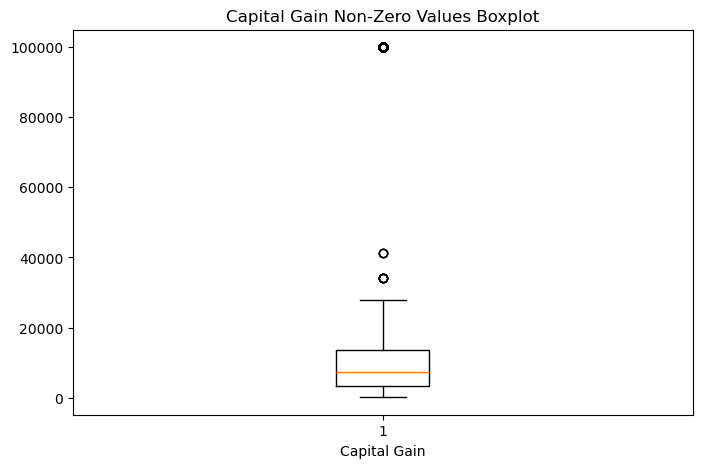

In [23]:
# Select non-zero capital_gain
capital_gain_non_zero = df_train_test[df_train_test['capital_gain'] > 0]['capital_gain']

# Q1 (25th percentile): value below which 25% of non-zero values fall
# Q3 (75th percentile): value below which 75% of non-zero values fall

Q1 = capital_gain_non_zero.quantile(0.25)
Q3 = capital_gain_non_zero.quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = capital_gain_non_zero[(capital_gain_non_zero < lower_bound) | (capital_gain_non_zero > upper_bound)]
print("Number of outliers:", len(outliers))



plt.figure(figsize=(8,5))
plt.boxplot(capital_gain_non_zero, vert=True)
plt.title("Capital Gain Non-Zero Values Boxplot")
plt.xlabel("Capital Gain")
plt.show()

In [24]:
# Filter outliers
#outliers = capital_gain_non_zero[capital_gain_non_zero > 28758.5]
outliers = capital_gain_non_zero[capital_gain_non_zero == 99999]

# Show all outlier values
print(outliers.count())

244


In [25]:
# Count outliers greater than upper bound but less than 99999
outliers_excl_max = capital_gain_non_zero[
    (capital_gain_non_zero > 28758.5) & (capital_gain_non_zero < 99999)
]

# Number of such outliers
print("Number of outliers > 28758.5 but < 99999:", len(outliers_excl_max))

# Optional: show these outlier values
print(outliers_excl_max.sort_values(ascending=False))

Number of outliers > 28758.5 but < 99999: 9
6433     41310
36166    41310
20176    41310
106      34095
4568     34095
15376    34095
7186     34095
17039    34095
36948    34095
Name: capital_gain, dtype: int64


In [26]:
df_train_test[df_train_test['capital_gain'] == 99999]['income'].value_counts()

income
>50K     159
>50K.     85
Name: count, dtype: int64

In [27]:
# capital gain rows has 92 % values as 0 and out of 253 non-zero rows, 244 rows has the data as 99999. 
# assuming 99999 is a capped value for higher gain. we are creating a new binary column for capital_gain 0 and 1.
df_train_test['capital_gain_bin'] = (df_train_test['capital_gain'] > 0).astype(int)

### Capital Loss column Data cleaning

In [28]:
df_train_test['capital_loss'].describe()

count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital_loss, dtype: float64

Lower bound: 1214.5
Upper bound: 2434.5
capital_loss - Number of outliers: 46715


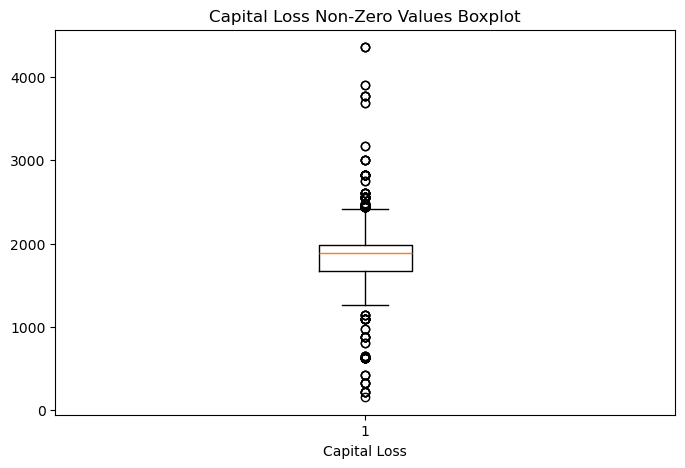

In [29]:
# Outlier detection and treatment for capital_loss using IQR

capital_loss_non_zero = df_train_test[df_train_test['capital_loss'] > 0]['capital_loss']

Q1 = capital_loss_non_zero.quantile(0.25)
Q3 = capital_loss_non_zero.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Detect outliers
outliers_loss = df_train_test[(df_train_test['capital_loss'] < lower_bound) | (df_train_test['capital_loss'] > upper_bound)]
print(f"{'capital_loss'} - Number of outliers: {outliers_loss.shape[0]}")

# Optional: Cap outliers to the bounds
#df_train_test[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

#print(f"Outlier detection and capping done for {'capital_loss'}.")



plt.figure(figsize=(8,5))
plt.boxplot(capital_loss_non_zero, vert=True)
plt.title("Capital Loss Non-Zero Values Boxplot")
plt.xlabel("Capital Loss")
plt.show()

### Non-zero capital loss values are right-skewed, with more extreme values on the higher end. IQR method detected outliers, but these values are valid and not capped.

In [30]:
# creatign the binary column for capital loss
df_train_test['capital_loss_bin'] = (df_train_test['capital_loss'] > 0).astype(int)

In [31]:
# create new column net_capital
df_train_test['net_capital'] = df_train_test['capital_gain'] - df_train_test['capital_loss']


In [32]:
# Shows the proportion of income categories within each capital_loss_bin(0,1).
# For bin 0, most people earn <=50K. For bin 1, income is almost evenly split.

df_train_test.groupby('capital_loss_bin')['income'].value_counts(normalize=True)


capital_loss_bin  income
0                 <=50K     0.514905
                  <=50K.    0.258655
                  >50K      0.151804
                  >50K.     0.074635
1                 >50K      0.338738
                  <=50K     0.326906
                  <=50K.    0.171779
                  >50K.     0.162577
Name: proportion, dtype: float64

### Hours Per Week data cleaning

In [33]:
df_train_test['hours_per_week'].isnull().sum()

np.int64(0)

In [34]:
df_train_test['hours_per_week'].sort_values().unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87,
       88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 99])

In [35]:
df_train_test['hours_per_week'].describe()

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours_per_week, dtype: float64

In [36]:
df_train_test['hours_per_week'].value_counts().head(10)

hours_per_week
40    22803
50     4246
45     2717
60     2177
35     1937
20     1862
30     1700
55     1051
25      958
48      770
Name: count, dtype: int64

In [37]:
df_train_test[df_train_test['hours_per_week'] > 60].shape[0]

1676

In [38]:
df_train_test['hours_per_week'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: hours_per_week
Non-Null Count  Dtype
--------------  -----
48842 non-null  int64
dtypes: int64(1)
memory usage: 381.7 KB


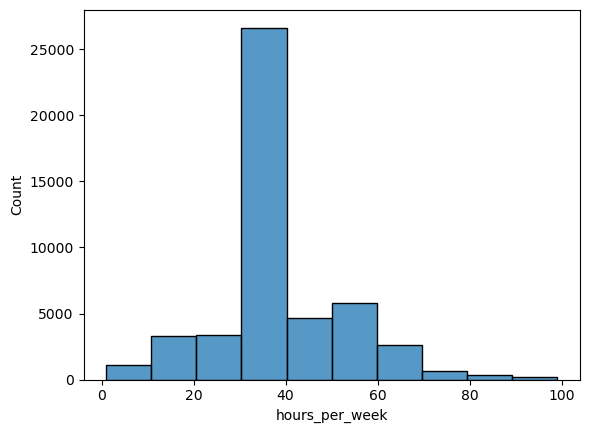

In [39]:
# check data distribution


sns.histplot(df_train_test['hours_per_week'], bins=10)
plt.show()

### Most people work around 40 hours per week, with a few unusually high values — the maximum is 99 hours, which could be possible for extended work schedules.

### Native Country cleaning

In [40]:
df_train_test['native_country'].describe()

count             47985
unique               41
top       United-States
freq              43832
Name: native_country, dtype: object

In [41]:
df_train_test['native_country'].value_counts()

native_country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

In [42]:
# checck for any null values
df_train_test['native_country'].isnull().sum()

np.int64(857)

In [43]:
# replace '?' with nan. This will conside nan as missing or null values. we can do our missing value analysis until we repalce nan with unknown.
df_train_test['native_country'] = df_train_test['native_country'].replace('?',np.nan)

In [44]:
df_train_test['native_country'] = df_train_test['native_country'].fillna('Unknown')

In [45]:
df_train_test['native_country'].unique()[:10]

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Unknown', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England'], dtype=object)

In [46]:
df_train_test['native_country'] = df_train_test['native_country'].str.strip()  

### Missing values represented by "?" were replaced with "Unknown". All other country names are valid, and no further modifications were applied

## Income

In [47]:

# standardize the income caegories

df_train_test['income'] = (df_train_test['income'].str.strip().str.replace('.','',regex=False))

# Check unique values after cleaning
print(df_train_test['income'].unique())

['<=50K' '>50K']


In [48]:
# Convert income to binary for modelling as Most ML models (logistic regression, random forest, XGBoost..) 
# require a numerical target for classification
df_train_test['income_binary'] = df_train_test['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Check the result
df_train_test['income_binary'].value_counts()


income_binary
0    37155
1    11687
Name: count, dtype: int64

### The income column had inconsistent categories (e.g., >50K, >50K., <50K, <50K.). These were standardized to two consistent labels: >50K and <50K. A binary column income_binary was created for modeling, with 1 representing >50K and 0 representing <=50K.

In [49]:
#checking marital status column
df_train_test['marital_status'].describe()

count                  48842
unique                     7
top       Married-civ-spouse
freq                   22379
Name: marital_status, dtype: object

In [50]:
df_train_test['marital_status'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: marital_status
Non-Null Count  Dtype 
--------------  ----- 
48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


### Marital Status has no missing values and outliers. No Data Cleaning required.

In [51]:
#checking occupation column
df_train_test['occupation'].isnull().sum()

np.int64(2809)

In [52]:
# replace '?' with nan. This will conside nan as missing or null values. we can do our missing value analysis until we repalce nan with unknown.
df_train_test['occupation'] = df_train_test['occupation'].fillna('Unknown')

In [53]:
df_train_test['occupation'].value_counts(dropna=False)

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Unknown              2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

### Occupation has 2809 missing values, we replaced with Unknown.

In [54]:
#relationship
df_train_test['relationship'].isnull().sum()


np.int64(0)

In [55]:
df_train_test['relationship'].describe()

count       48842
unique          6
top       Husband
freq        19716
Name: relationship, dtype: object

###  relationship has no missing values and outliers. No Data cleaning needed.

In [56]:
#race column 
df_train_test['race'].isnull().sum()

np.int64(0)

In [57]:
df_train_test['race'].value_counts()

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

In [58]:
df_train_test['race'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: race
Non-Null Count  Dtype 
--------------  ----- 
48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


### race has no missing values and outliers. No Data Cleaning needed.

In [59]:
#sex column
df_train_test['sex'].isna().sum()

np.int64(0)

In [60]:
df_train_test['sex'].describe()

count     48842
unique        2
top        Male
freq      32650
Name: sex, dtype: object

### sex has no missing values and outliers. No Data cleaning needed.

In [61]:
df_train_test[df_train_test.duplicated()]


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K,train,0,0,0,0
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K,train,0,0,0,0
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K,train,0,0,0,0
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K,train,0,0,0,0
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K,train,0,0,0,0
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K,train,0,0,0,0
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,Unknown,<=50K,train,0,0,0,0
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K,train,0,0,0,0


In [63]:
df_train_test[df_train_test.duplicated(keep=False)]


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
2303,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K,train,0,0,0,0
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K,train,0,0,0,0
4325,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K,train,0,0,0,0
4767,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K,train,0,0,0,0
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K,train,0,0,0,0
4940,38,Private,207202,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,48,United-States,>50K,train,0,0,0,1
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K,train,0,0,0,0
5579,27,Private,255582,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K,train,0,0,0,0
5805,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K,train,0,0,0,0
5842,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K,train,0,0,0,0
